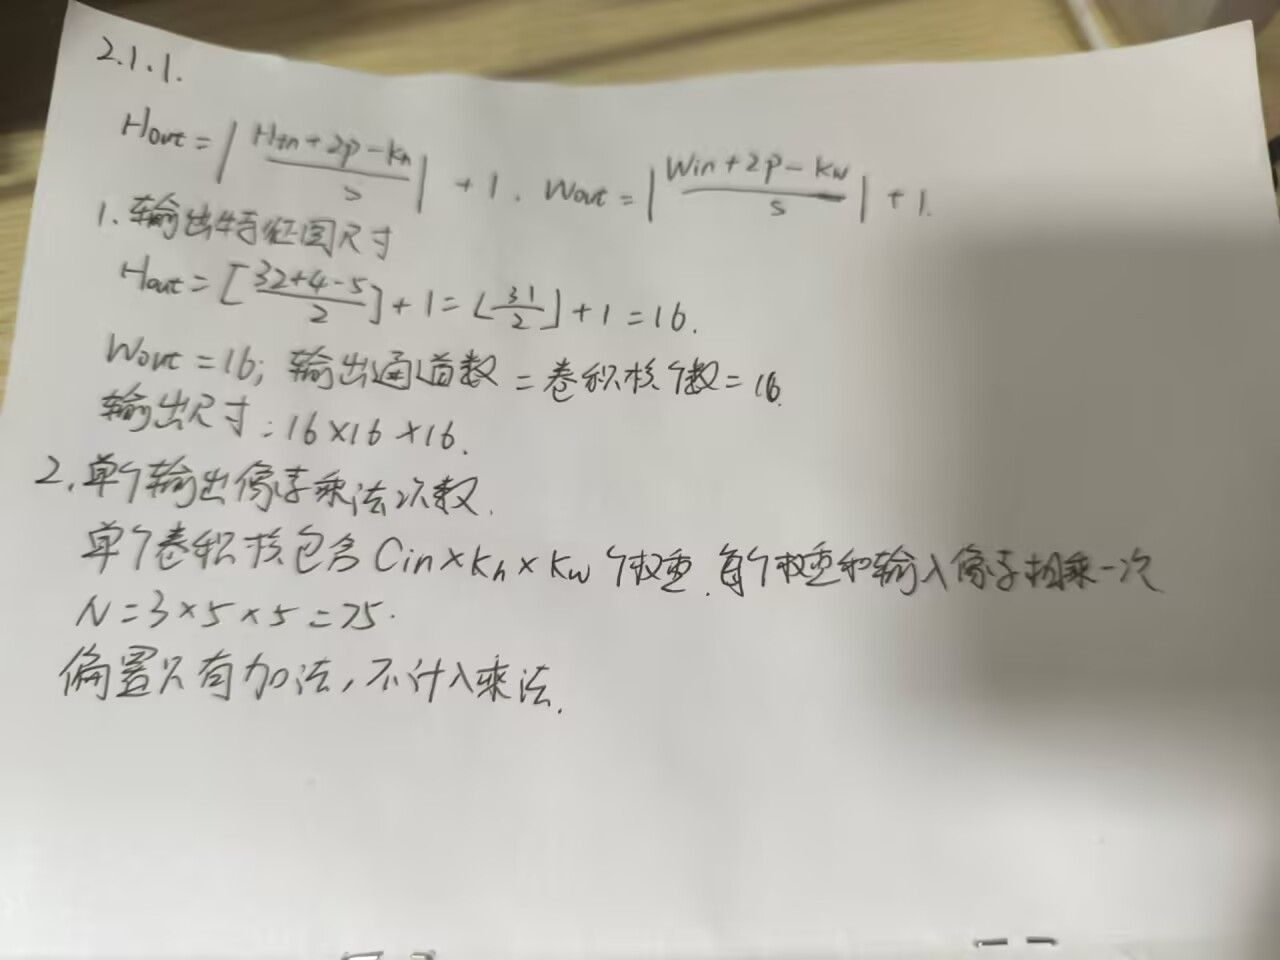

In [1]:
import numpy as np

def manual_max_pool2d_np(input_x, kernel_size, stride, padding):
    """
    手动实现二维最大池化前向传播，无框架Pooling API
    :param input_x: np.ndarray, shape [N, C, Hin, Win]
    :param kernel_size: int / (kh, kw) 池化核尺寸
    :param stride: int / (sh, sw) 步幅
    :param padding: int / (ph, pw) 填充大小
    :return: 池化输出 [N, C, Hout, Wout]
    """
    # 参数统一拆分为二元组
    if isinstance(kernel_size, int):
        kh, kw = kernel_size, kernel_size
    else:
        kh, kw = kernel_size
    if isinstance(stride, int):
        sh, sw = stride, stride
    else:
        sh, sw = stride
    if isinstance(padding, int):
        ph, pw = padding, padding
    else:
        ph, pw = padding

    N, C, Hin, Win = input_x.shape

    # 四周零填充，仅在H、W维度填充，batch和通道不填充
    pad_width = ((0, 0), (0, 0), (ph, ph), (pw, pw))
    x_pad = np.pad(input_x, pad_width, mode="constant", constant_values=0)

    # 计算输出高、宽
    Hout = (Hin + 2 * ph - kh) // sh + 1
    Wout = (Win + 2 * pw - kw) // sw + 1

    # 初始化输出数组
    pool_out = np.zeros((N, C, Hout, Wout), dtype=np.float32)

    # 滑动窗口遍历每个输出位置
    for n in range(N):
        for c in range(C):
            for oh in range(Hout):
                h_start = oh * sh
                h_end = h_start + kh
                for ow in range(Wout):
                    w_start = ow * sw
                    w_end = w_start + kw
                    window = x_pad[n, c, h_start:h_end, w_start:w_end]
                    pool_out[n, c, oh, ow] = np.max(window)

    return pool_out

In [2]:
# 构造测试输入：N=2, C=3, H=8, W=8
x_np = np.random.randint(0, 20, size=(2, 3, 8, 8)).astype(np.float32)

# 池化超参数
k_size = 2
stride = 2
pad = 0

# 执行手动池化
out_np = manual_max_pool2d_np(x_np, k_size, stride, pad)

print("输入张量shape:", x_np.shape)
print("池化输出shape:", out_np.shape)
print("\n第一个样本第一个通道原始特征：")
print(x_np[0, 0])
print("\n池化后对应通道结果：")
print(out_np[0, 0])

输入张量shape: (2, 3, 8, 8)
池化输出shape: (2, 3, 4, 4)

第一个样本第一个通道原始特征：
[[ 2. 17.  0. 17. 17.  9. 16.  9.]
 [ 2.  5.  4.  0.  7. 11.  6. 14.]
 [12. 14. 18.  0.  6.  9.  9.  8.]
 [14.  5. 12.  6. 18.  1.  3. 16.]
 [ 0.  5.  7.  0.  8.  9. 10. 16.]
 [18.  4. 12.  3. 15. 14. 19.  8.]
 [ 9. 18.  7. 17.  6.  9. 13. 16.]
 [ 4.  4.  3. 13. 10.  2. 14. 10.]]

池化后对应通道结果：
[[17. 17. 17. 16.]
 [14. 18. 18. 16.]
 [18. 12. 15. 19.]
 [18. 17. 10. 16.]]


In [ ]:

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
     -------------------------------------- 201.8/201.8 MB 1.7 MB/s eta 0:00:00
     ---------------------------------------- 1.3/1.3 MB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 1.9 MB/s eta 0:00:00


In [5]:
import torch

def manual_max_pool2d_torch(input_x, kernel_size, stride, padding):
    if isinstance(kernel_size, int):
        kh, kw = kernel_size, kernel_size
    else:
        kh, kw = kernel_size
    if isinstance(stride, int):
        sh, sw = stride, stride
    else:
        sh, sw = stride
    if isinstance(padding, int):
        ph, pw = padding, padding
    else:
        ph, pw = padding

    N, C, Hin, Win = input_x.shape
    # 手动填充，不用池化API
    x_pad = torch.nn.functional.pad(input_x, (pw, pw, ph, ph), mode="constant", value=0.0)

    Hout = (Hin + 2 * ph - kh) // sh + 1
    Wout = (Win + 2 * pw - kw) // sw + 1

    pool_out = torch.zeros((N, C, Hout, Wout), device=input_x.device, dtype=input_x.dtype)

    for n in range(N):
        for c in range(C):
            for oh in range(Hout):
                hs = oh * sh
                he = hs + kh
                for ow in range(Wout):
                    ws = ow * sw
                    we = ws + kw
                    window = x_pad[n, c, hs:he, ws:we]
                    pool_out[n, c, oh, ow] = torch.max(window)
    return pool_out

In [6]:
# 构造torch测试张量
x_torch = torch.randint(0, 20, (2, 3, 8, 8)).float()
out_torch = manual_max_pool2d_torch(x_torch, kernel_size=2, stride=2, padding=0)

print("torch输入shape:", x_torch.shape)
print("torch手动池化输出shape:", out_torch.shape)


torch输入shape: torch.Size([2, 3, 8, 8])
torch手动池化输出shape: torch.Size([2, 3, 4, 4])


In [ ]:

import torch.nn as nn

official_pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
out_official = official_pool(x_torch)

print("官方MaxPool2d输出shape:", out_official.shape)
# 比对数值误差
diff = torch.abs(out_torch - out_official)
print("手动实现与官方API最大误差：", torch.max(diff).item())

官方MaxPool2d输出shape: torch.Size([2, 3, 4, 4])
手动实现与官方API最大误差： 0.0


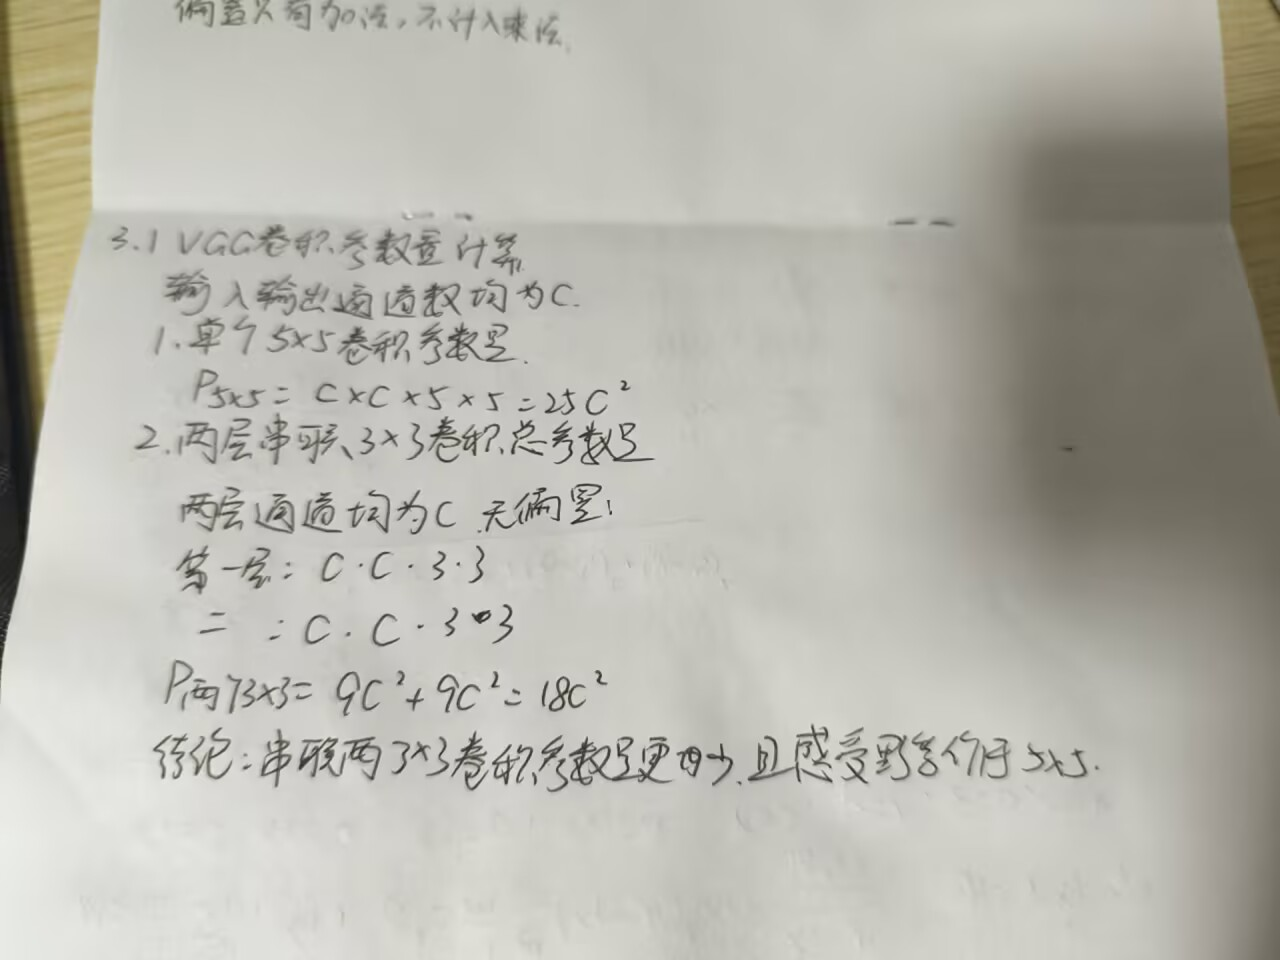

In [8]:
import torch
import torch.nn as nn

def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    构造标准NiN块
    :param in_channels: 输入通道数
    :param out_channels: 输出通道数
    :param kernel_size: 首个常规卷积核大小
    :param stride: 首个卷积步幅
    :param padding: 首个卷积填充
    :return: nn.Sequential封装的NiN块
    """
    block = nn.Sequential(
        # 第一个常规卷积
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.ReLU(inplace=True),
        # 第一个1×1卷积
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
        # 第二个1×1卷积
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True)
    )
    return block

In [ ]:

nin_blk = nin_block(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

x = torch.randn(2, 3, 32, 32)

y = nin_blk(x)

print("输入张量 shape:", x.shape)
print("NiN块输出 shape:", y.shape)
print("\nNiN块网络结构：")
print(nin_blk)

输入张量 shape: torch.Size([2, 3, 32, 32])
NiN块输出 shape: torch.Size([2, 16, 32, 32])

NiN块网络结构：
Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU(inplace=True)
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU(inplace=True)
)


In [ ]:

class SimpleNiN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nin_block(3, 96, kernel_size=11, stride=4, padding=0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nin_block(96, 256, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nin_block(256, 384, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nin_block(384, num_classes, kernel_size=3, stride=1, padding=1),
            # 全局平均池化代替FC层
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
    
    def forward(self, x):
        return self.net(x)

model = SimpleNiN(num_classes=10)
test_x = torch.randn(4, 3, 224, 224)
out = model(test_x)
print("完整NiN网络输出shape（batch, classes）:", out.shape)

完整NiN网络输出shape（batch, classes）: torch.Size([4, 10])


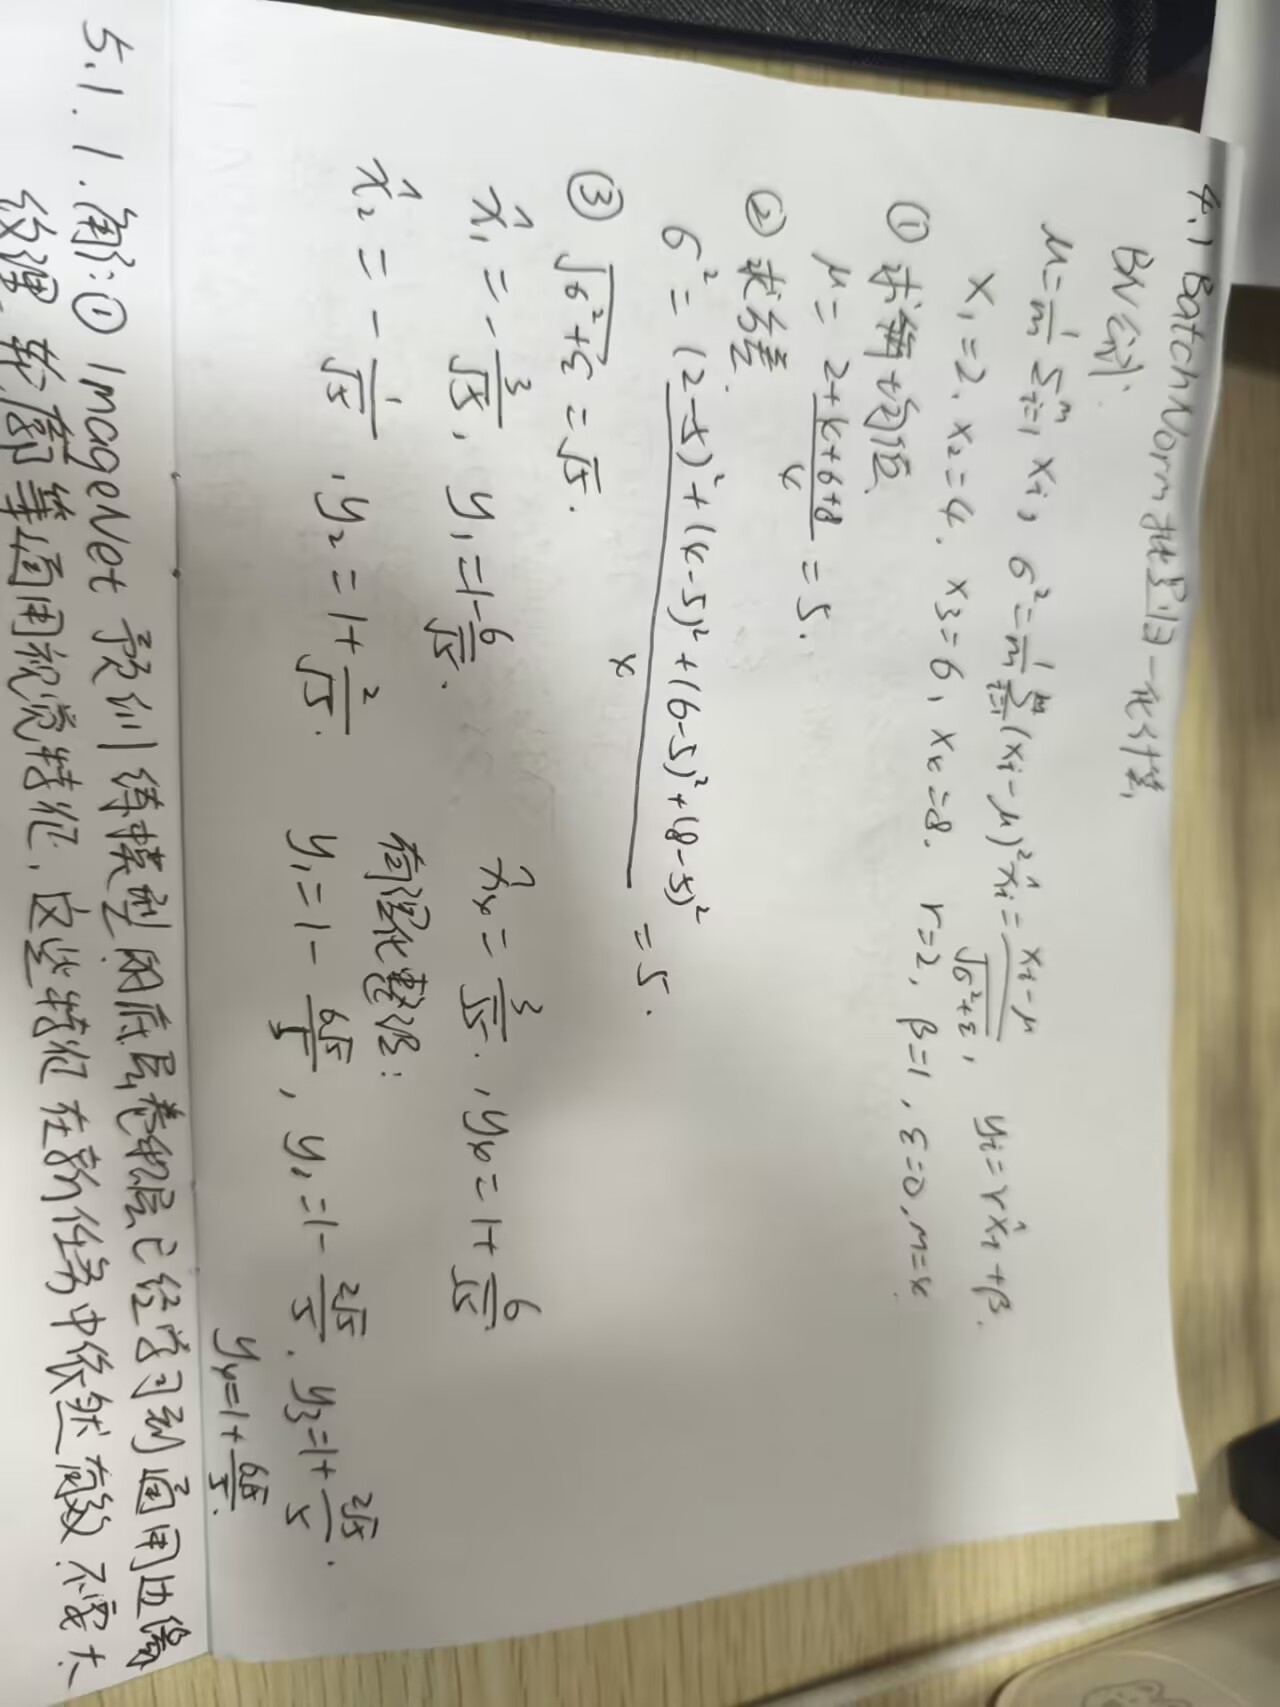

In [ ]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_1x1conv=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                                   stride=stride, bias=False)
        else:
            self.conv3 = None
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # 主干前向
        y = self.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        # 捷径分支适配
        if self.conv3 is not None:
            x = self.conv3(x)
        
        # 残差相加 y = F(x)+x
        y += x
        y = self.relu(y)
        return y

In [ ]:

blk1 = Residual(in_channels=64, out_channels=64, stride=1, use_1x1conv=False)
x1 = torch.randn(2, 64, 32, 32)
y1 = blk1(x1)

print("=== 不使用1×1卷积捷径 ===")
print("输入shape: ", x1.shape)
print("输出shape: ", y1.shape)

=== 不使用1×1卷积捷径 ===
输入shape:  torch.Size([2, 64, 32, 32])
输出shape:  torch.Size([2, 64, 32, 32])


In [ ]:

blk2 = Residual(in_channels=64, out_channels=128, stride=2, use_1x1conv=True)
x2 = torch.randn(2, 64, 32, 32)
y2 = blk2(x2)

print("\n=== 使用1×1卷积捷径（通道+下采样） ===")
print("输入shape: ", x2.shape)
print("输出shape: ", y2.shape)


=== 使用1×1卷积捷径（通道+下采样） ===
输入shape:  torch.Size([2, 64, 32, 32])
输出shape:  torch.Size([2, 128, 16, 16])


In [14]:
print("\n残差块完整结构：")
print(blk2)


残差块完整结构：
Residual(
  (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
  (relu): ReLU(inplace=True)
)


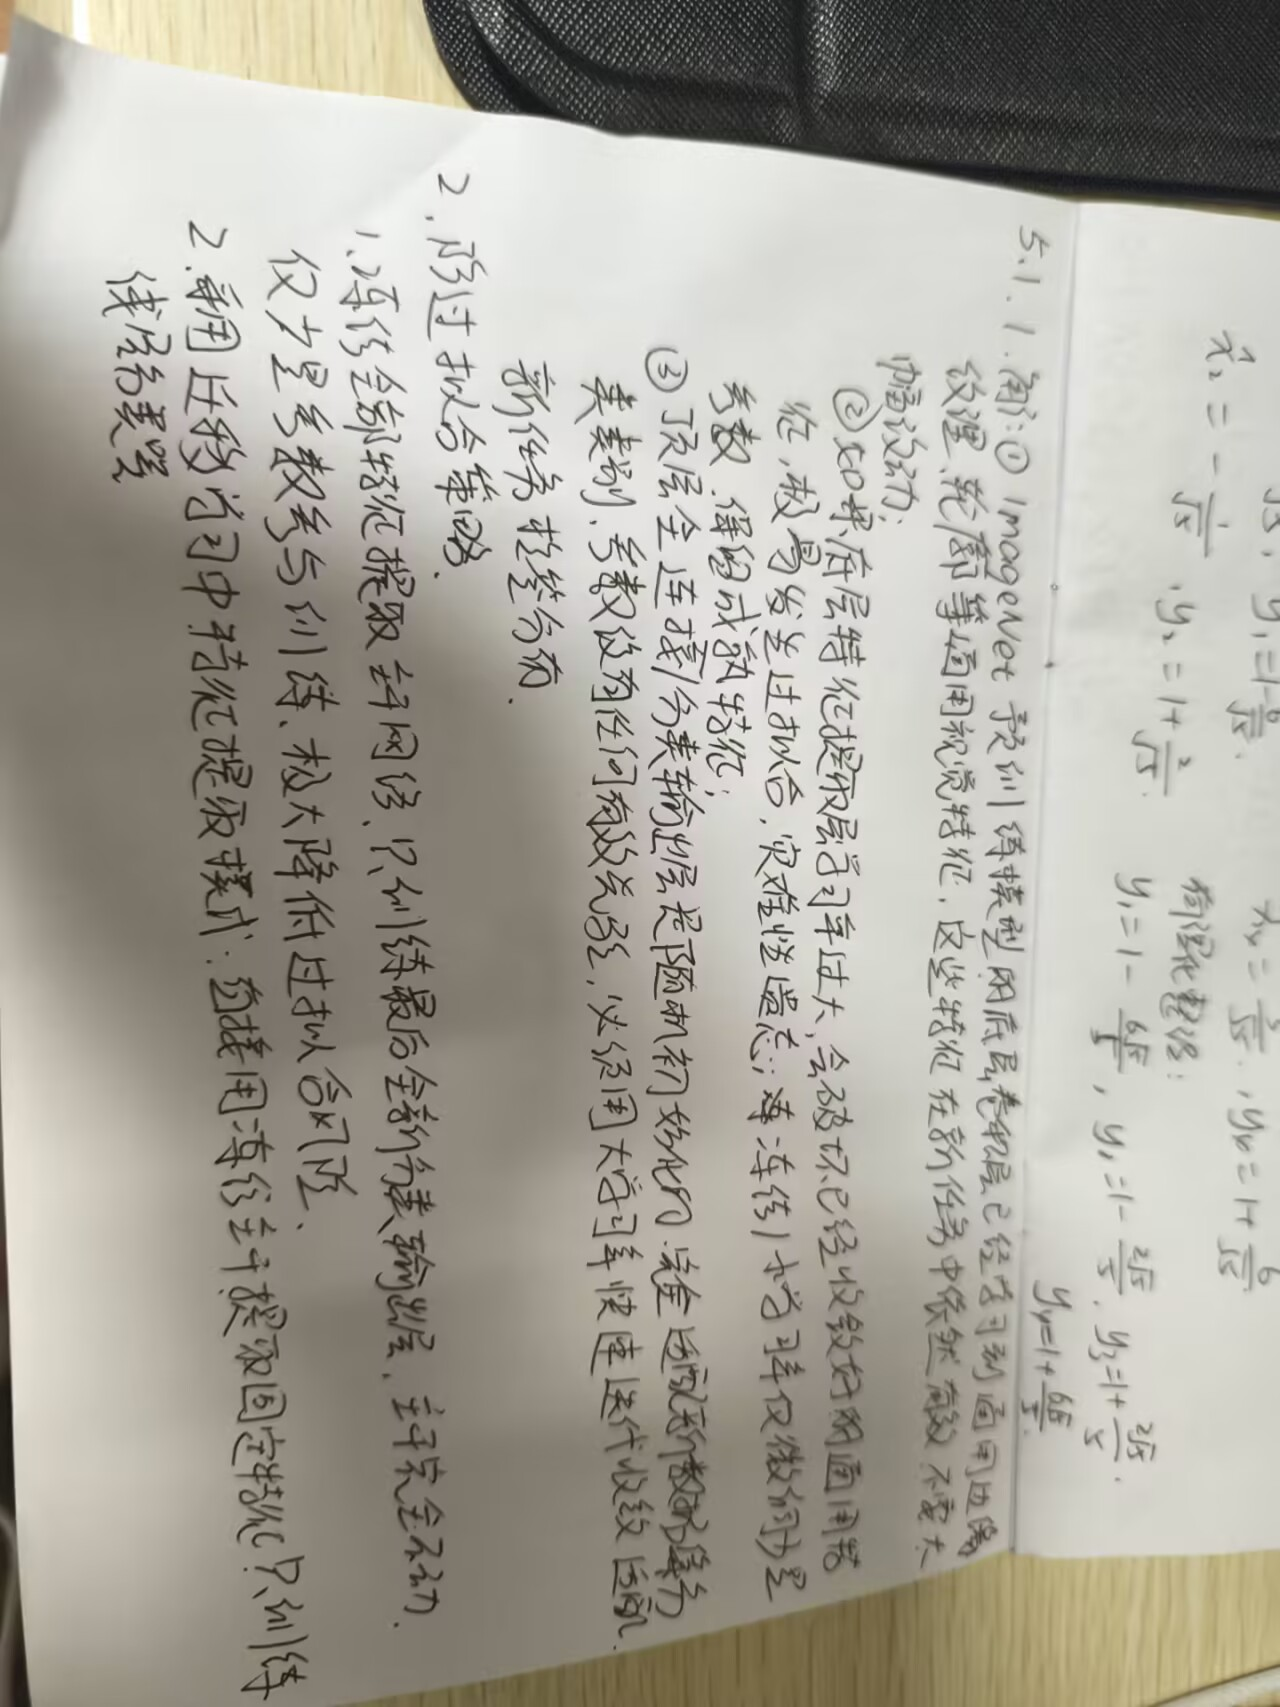

In [15]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:

aug_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.08, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5,
        hue=0.0  
    ),
    transforms.ToTensor()
])

print("图像增广流水线完整结构：")
print(aug_pipeline)

图像增广流水线完整结构：
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)


c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 21407 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22270 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 22686 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 24191 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 21407 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 22270 missing from cur

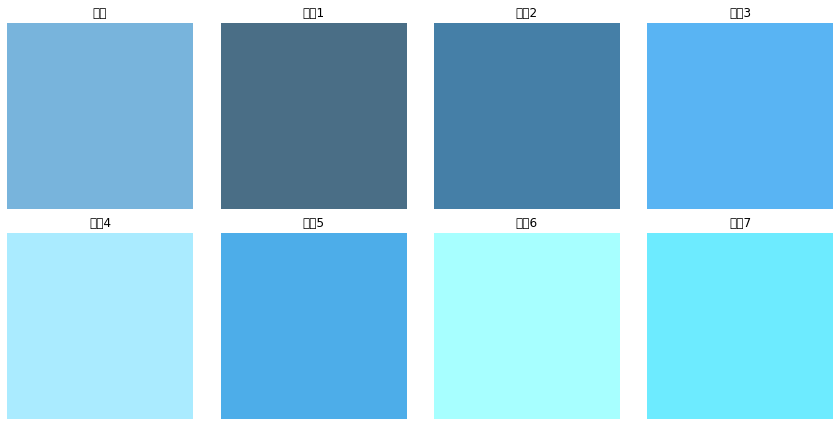

增广后张量shape (C, H, W): torch.Size([3, 224, 224])


In [ ]:

img = Image.new("RGB", (400, 400), color=(120, 180, 220))

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title("原图")
plt.axis("off")


for i in range(7):
    tensor_img = aug_pipeline(img)
    pil_aug = transforms.ToPILImage()(tensor_img)
    plt.subplot(2, 4, i+2)
    plt.imshow(pil_aug)
    plt.title(f"增广{i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

tensor_img = aug_pipeline(img)
print(f"增广后张量shape (C, H, W): {tensor_img.shape}")

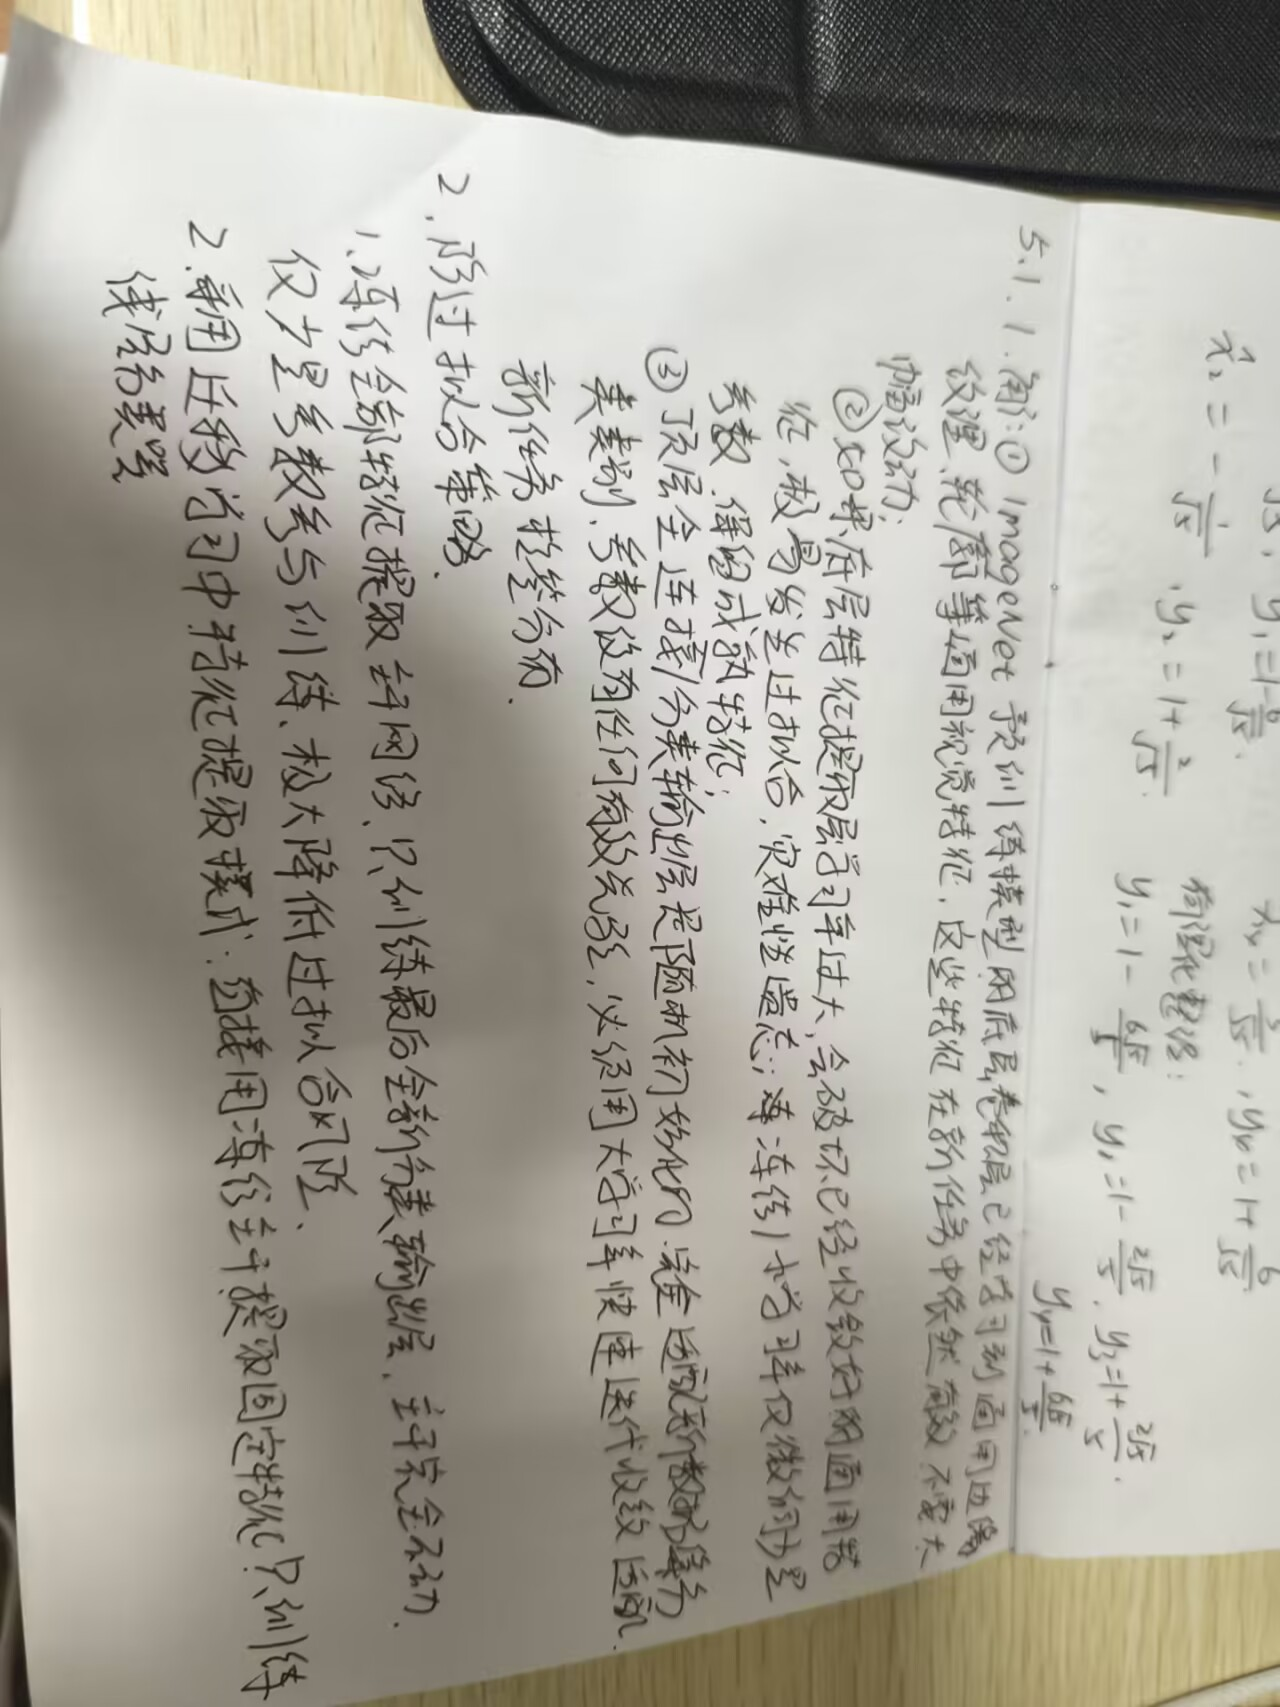

In [20]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
train_aug = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor()
])

print("图像增广流水线结构：")
print(train_aug)

图像增广流水线结构：
Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)


c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 26679 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 26412 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 26679 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\swl-9\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 26412 missing from current font.
  font.set_text(s, 0, flags=flags)


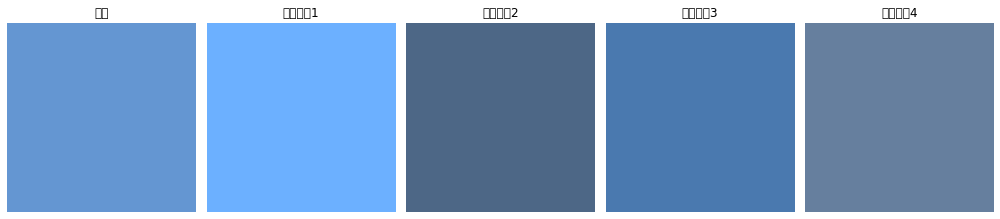

增广后张量形状 [C, H, W]：torch.Size([3, 224, 224])


In [ ]:

origin_img = Image.new("RGB", (400, 400), color=(100, 150, 210))

plt.figure(figsize=(14, 3))
plt.subplot(1, 5, 1)
plt.imshow(origin_img)
plt.title("原图")
plt.axis("off")

for i in range(4):
    aug_tensor = train_aug(origin_img)
    aug_pil = transforms.ToPILImage()(aug_tensor)
    plt.subplot(1, 5, i+2)
    plt.imshow(aug_pil)
    plt.title(f"增广样本{i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 输出张量维度校验
single_tensor = train_aug(origin_img)
print(f"增广后张量形状 [C, H, W]：{single_tensor.shape}")